In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Scikit-Learn:", sklearn.__version__)

NumPy: 2.1.3
Pandas: 2.2.3
Scikit-Learn: 1.6.1


In [2]:
# ============================================
# DOWNLOAD ALL DATASETS FOR ML LAB
# ============================================

import pandas as pd
import requests
import zipfile
import io
import os

# Create data folder
os.makedirs("/content/data", exist_ok=True)

# ------------------------------------------------
# 1. Insurance Dataset
# ------------------------------------------------

insurance_url = "https://raw.githubusercontent.com/pycaret/pycaret/main/datasets/insurance.csv"

response = requests.get(insurance_url)
response.raise_for_status()

with open("/content/data/insurance.csv", "wb") as f:
    f.write(response.content)

print("✓ insurance.csv downloaded")


# ------------------------------------------------
# 2. Bank Marketing Dataset
# ------------------------------------------------

bank_url = "https://archive.ics.uci.edu/static/public/222/bank+marketing.zip"

response = requests.get(bank_url)
response.raise_for_status()

with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    z.extractall("/content/data/bank")

print("✓ Bank Marketing dataset downloaded")


# ------------------------------------------------
# 3. Wholesale Customers Dataset
# ------------------------------------------------

wholesale_url = "https://archive.ics.uci.edu/static/public/292/wholesale+customers.zip"

response = requests.get(wholesale_url)
response.raise_for_status()

with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    z.extractall("/content/data/wholesale")

print("✓ Wholesale Customers dataset downloaded")


print("\nAll datasets downloaded successfully!")

✓ insurance.csv downloaded
✓ Bank Marketing dataset downloaded
✓ Wholesale Customers dataset downloaded

All datasets downloaded successfully!


In [3]:
import os

for root, dirs, files in os.walk("/content/data"):
    level = root.replace("/content/data", "").count(os.sep)
    indent = "    " * level
    print(indent + os.path.basename(root) + "/")

    for file in files:
        print(indent + "    " + file)

data/
    insurance.csv
    bank/
        bank.zip
        bank-additional.zip
    wholesale/
        Wholesale customers data.csv


In [4]:
insurance = pd.read_csv("/content/data/insurance.csv")

print(insurance.shape)
print(insurance.columns.tolist())
insurance.head()

(1338, 7)
['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
import pandas as pd
import numpy as np

insurance = pd.read_csv("/content/data/insurance.csv")

print("Shape:", insurance.shape)
print("\nColumns:")
print(insurance.columns.tolist())

print("\nFirst 5 rows:")
display(insurance.head())

Shape: (1338, 7)

Columns:
['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

First 5 rows:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [6]:
print("Dataset Information:")
insurance.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [7]:
print("\nMissing Values:")
print(insurance.isnull().sum())


Missing Values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [8]:
print("\nDuplicate Rows:")
print(insurance.duplicated().sum())


Duplicate Rows:
1


In [9]:
print("\nStatistical Summary:")
display(insurance.describe())


Statistical Summary:


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [10]:
charges_skewness = insurance["charges"].skew()

print(f"Charges skewness: {charges_skewness:.4f}")

Charges skewness: 1.5159


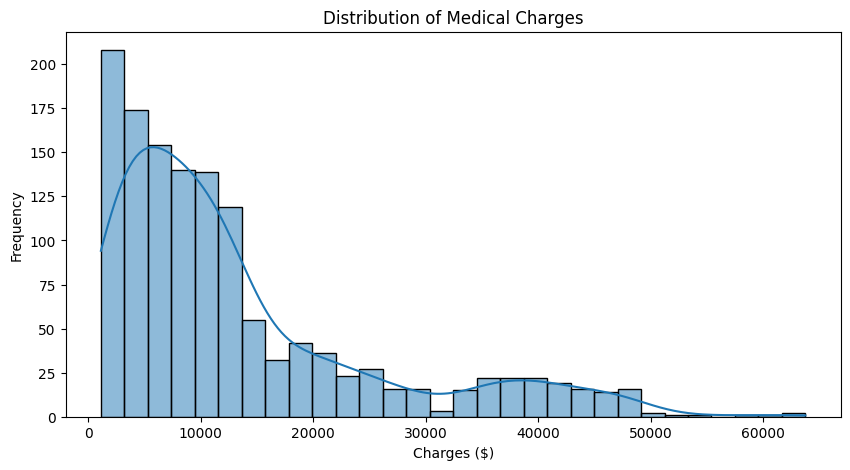

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

sns.histplot(
    insurance["charges"],
    kde=True
)

plt.title("Distribution of Medical Charges")
plt.xlabel("Charges ($)")
plt.ylabel("Frequency")

plt.show()

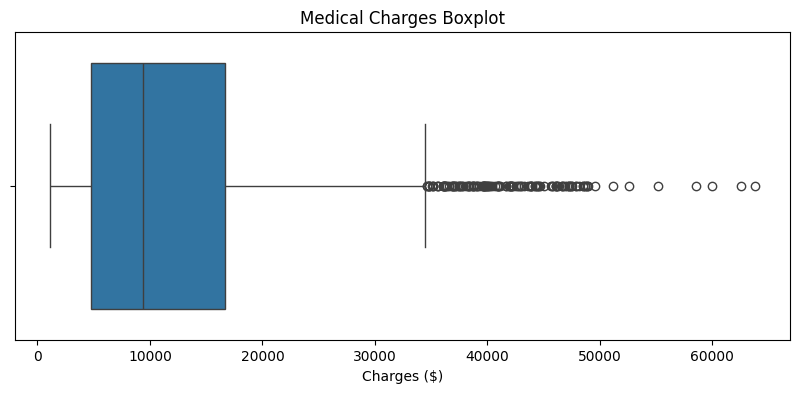

In [12]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    x=insurance["charges"]
)

plt.title("Medical Charges Boxplot")
plt.xlabel("Charges ($)")

plt.show()

In [13]:
X = insurance.drop(columns=["charges"])
y = insurance["charges"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1338, 6)
y shape: (1338,)


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 1070
Testing rows: 268


In [15]:
num_cols = [
    "age",
    "bmi",
    "children"
]

cat_cols = [
    "sex",
    "smoker",
    "region"
]

print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

Numerical columns: ['age', 'bmi', 'children']
Categorical columns: ['sex', 'smoker', 'region']


In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            num_cols
        ),
        (
            "cat",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            ),
            cat_cols
        )
    ]
)

In [17]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

model_pipeline = Pipeline(
    steps=[
        ("prep", preprocessor),
        ("regressor", LinearRegression())
    ]
)

print(model_pipeline)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('regressor', LinearRegression())])


In [18]:
model_pipeline.fit(X_train, y_train)

print("Model training completed successfully.")

Model training completed successfully.


In [19]:
predictions = model_pipeline.predict(X_test)

print("First 10 predictions:")
print(predictions[:10])

First 10 predictions:
[ 8969.55027444  7068.74744287 36858.41091155  9454.67850053
 26973.17345656 10864.11316424   170.28084136 16903.45028662
  1092.43093614 11218.34318352]


In [20]:
from sklearn.metrics import mean_squared_error, r2_score

r2 = r2_score(y_test, predictions)

rmse = np.sqrt(
    mean_squared_error(y_test, predictions)
)

print("=" * 50)
print("LINEAR REGRESSION RESULTS")
print("=" * 50)

print(f"R² Score : {r2:.4f}")
print(f"RMSE     : ${rmse:,.2f}")

LINEAR REGRESSION RESULTS
R² Score : 0.7836
RMSE     : $5,796.28


In [21]:
results = pd.DataFrame({
    "Actual Charges": y_test.values,
    "Predicted Charges": predictions,
    "Residual": y_test.values - predictions
})

display(results.head(10))

,Actual Charges,Predicted Charges,Residual
0,9095.06825,8969.550274,125.517976
1,5272.17580,7068.747443,-1796.571643
2,29330.98315,36858.410912,-7527.427762
3,9301.89355,9454.678501,-152.784951
4,33750.29180,26973.173457,6777.118343
5,4536.25900,10864.113164,-6327.854164
6,2117.33885,170.280841,1947.058009
7,14210.53595,16903.450287,-2692.914337
8,3732.62510,1092.430936,2640.194164
9,10264.44210,11218.343184,-953.901084


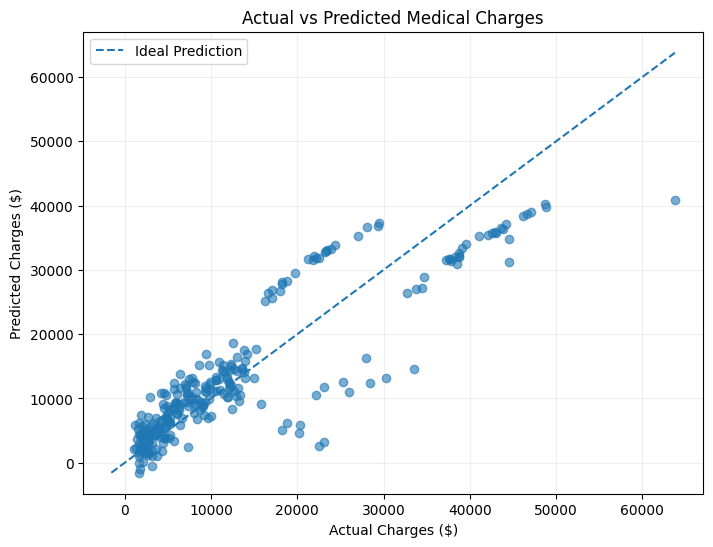

In [22]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    predictions,
    alpha=0.6
)

min_value = min(
    y_test.min(),
    predictions.min()
)

max_value = max(
    y_test.max(),
    predictions.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    label="Ideal Prediction"
)

plt.xlabel("Actual Charges ($)")
plt.ylabel("Predicted Charges ($)")
plt.title("Actual vs Predicted Medical Charges")

plt.legend()
plt.grid(alpha=0.2)

plt.show()

In [23]:
residuals = y_test - predictions

print("Mean residual:", residuals.mean())
print("Minimum residual:", residuals.min())
print("Maximum residual:", residuals.max())

Mean residual: -219.24066962508465
Minimum residual: -10512.582562011688
Maximum residual: 22850.136498353953


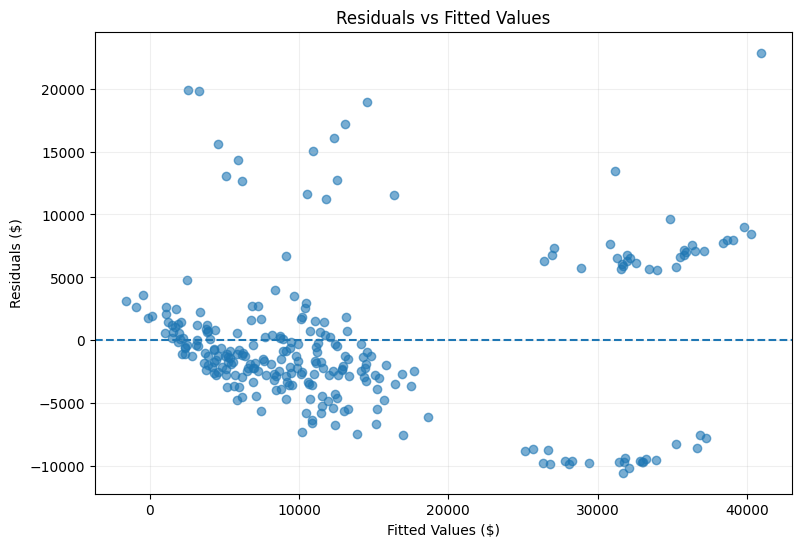

In [24]:
plt.figure(figsize=(9, 6))

plt.scatter(
    predictions,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Fitted Values ($)")
plt.ylabel("Residuals ($)")
plt.title("Residuals vs Fitted Values")

plt.grid(alpha=0.2)

plt.show()

In [25]:
feature_names = (
    model_pipeline
    .named_steps["prep"]
    .get_feature_names_out()
)

coefficients = (
    model_pipeline
    .named_steps["regressor"]
    .coef_
)

intercept = (
    model_pipeline
    .named_steps["regressor"]
    .intercept_
)

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coef_df = coef_df.sort_values(
    by="Coefficient",
    ascending=False
)

print(f"Intercept: ${intercept:,.2f}")

display(coef_df)

Intercept: $8,955.24


,Feature,Coefficient
4,cat__smoker_yes,23651.128856
0,num__age,3614.975415
1,num__bmi,2036.228123
2,num__children,516.890247
3,cat__sex_male,-18.591692
5,cat__region_northwest,-370.677326
6,cat__region_southeast,-657.864297
7,cat__region_southwest,-809.799354


In [26]:
smoker_coefficients = coef_df[
    coef_df["Feature"].str.contains(
        "smoker",
        case=False
    )
]

display(smoker_coefficients)

,Feature,Coefficient
4,cat__smoker_yes,23651.128856


In [27]:
import os

os.makedirs(
    "/content/outputs/predictions",
    exist_ok=True
)

In [28]:
results.to_csv(
    "/content/outputs/predictions/exercise1_insurance_predictions.csv",
    index=False
)

print("Prediction CSV saved successfully.")

Prediction CSV saved successfully.


In [29]:
from google.colab import files

files.download(
    "/content/outputs/predictions/exercise1_insurance_predictions.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [30]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

print("Original target example:")
print(y_train.head())

print("\nLog-transformed target example:")
print(y_train_log.head())

Original target example:
560      9193.83850
1285     8534.67180
1142    27117.99378
969      8596.82780
486     12475.35130
Name: charges, dtype: float64

Log-transformed target example:
560      9.126398
1285     9.052009
1142    10.207990
969      9.059265
486      9.431590
Name: charges, dtype: float64


In [31]:
log_model_pipeline = Pipeline(
    steps=[
        ("prep", preprocessor),
        ("regressor", LinearRegression())
    ]
)

In [32]:
log_model_pipeline.fit(
    X_train,
    y_train_log
)

print("Log-target model trained successfully.")

Log-target model trained successfully.


In [33]:
log_predictions = log_model_pipeline.predict(X_test)

print("First 10 log-scale predictions:")
print(log_predictions[:10])

First 10 log-scale predictions:
[ 9.11470731  8.6312095  11.09876796  9.11839303  9.55219508  8.68986209
  7.94709785  9.62278874  8.24058951  9.26115706]


In [34]:
log_predictions_dollars = np.expm1(log_predictions)

print("First 10 predictions in dollars:")
print(log_predictions_dollars[:10])

First 10 predictions in dollars:
[ 9086.97428249  5602.85203142 66088.68459689  9120.53183141
 14074.55781985  5941.36266338  2826.35761405 15104.11550605
  3790.77494406 10520.30011917]


In [35]:
log_r2 = r2_score(
    y_test,
    log_predictions_dollars
)

log_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        log_predictions_dollars
    )
)

print("=" * 50)
print("LOG1P LINEAR REGRESSION RESULTS")
print("=" * 50)

print(f"R² Score : {log_r2:.4f}")
print(f"RMSE     : ${log_rmse:,.2f}")

LOG1P LINEAR REGRESSION RESULTS
R² Score : 0.6067
RMSE     : $7,814.06


In [36]:
comparison = pd.DataFrame({
    "Model": [
        "Raw Target Linear Regression",
        "Log1p Target Linear Regression"
    ],
    "R2": [
        r2,
        log_r2
    ],
    "RMSE": [
        rmse,
        log_rmse
    ]
})

display(comparison)

,Model,R2,RMSE
0,Raw Target Linear Regression,0.783593,5796.284659
1,Log1p Target Linear Regression,0.606698,7814.064026


In [37]:
log_residuals = y_test - log_predictions_dollars


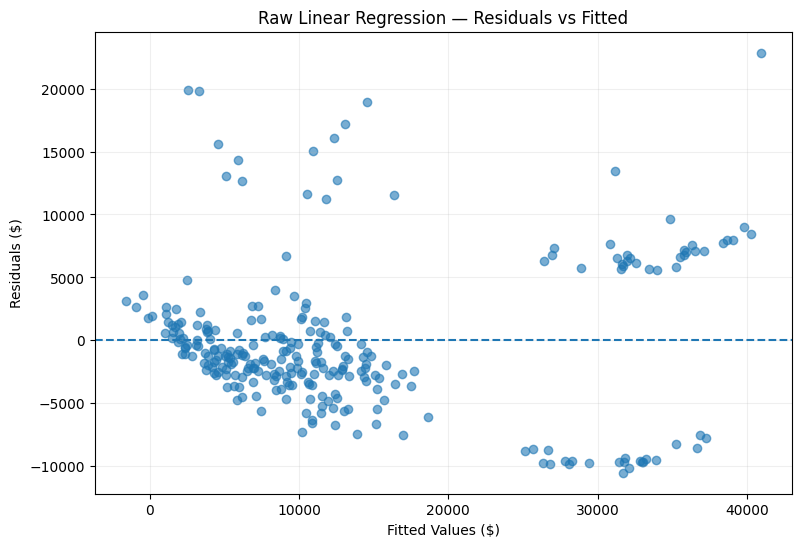

In [38]:
plt.figure(figsize=(9, 6))

plt.scatter(
    predictions,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Fitted Values ($)")
plt.ylabel("Residuals ($)")
plt.title("Raw Linear Regression — Residuals vs Fitted")

plt.grid(alpha=0.2)
plt.show()

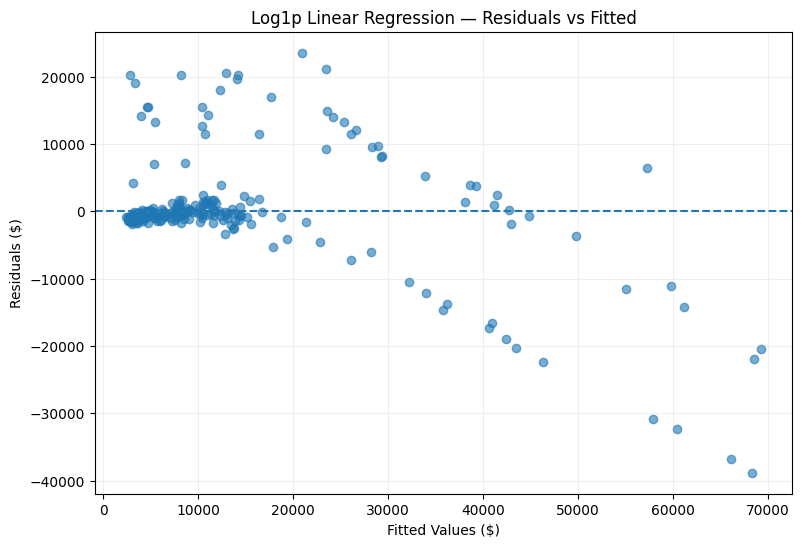

In [39]:
plt.figure(figsize=(9, 6))

plt.scatter(
    log_predictions_dollars,
    log_residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Fitted Values ($)")
plt.ylabel("Residuals ($)")
plt.title("Log1p Linear Regression — Residuals vs Fitted")

plt.grid(alpha=0.2)
plt.show()

In [40]:
print("=" * 60)
print("EXERCISE 1 — MODEL COMPARISON")
print("=" * 60)

print(f"{'Metric':<15}{'Raw Model':>20}{'Log1p Model':>20}")
print("-" * 55)

print(
    f"{'R²':<15}"
    f"{r2:>20.4f}"
    f"{log_r2:>20.4f}"
)

print(
    f"{'RMSE':<15}"
    f"${rmse:>19,.2f}"
    f"${log_rmse:>19,.2f}"
)

EXERCISE 1 — MODEL COMPARISON
Metric                    Raw Model         Log1p Model
-------------------------------------------------------
R²                           0.7836              0.6067
RMSE           $           5,796.28$           7,814.06


In [41]:
raw_pass = (r2 >= 0.75) and (rmse < 4800)
log_pass = (log_r2 >= 0.75) and (log_rmse < 4800)

print("Raw model meets acceptance criteria:", raw_pass)
print("Log1p model meets acceptance criteria:", log_pass)

Raw model meets acceptance criteria: False
Log1p model meets acceptance criteria: False


In [42]:
comparison.to_csv(
    "/content/outputs/exercise1_model_comparison.csv",
    index=False
)

print("Exercise 1 comparison saved.")

Exercise 1 comparison saved.


## Exercise 1 — Conclusion

A Multiple Linear Regression model was developed to predict individual
medical insurance charges.

The dataset was divided into 80% training and 20% testing data using
random_state=42. Numerical variables were standardized using
StandardScaler, while categorical variables were encoded using
OneHotEncoder with drop='first'.

The raw-target model achieved an R² of [VALUE] and an RMSE of [VALUE].

A second model using a log1p-transformed target was evaluated on the
original dollar scale. It achieved an R² of [VALUE] and an RMSE of
[VALUE].

The smoker coefficient was approximately $23,651, confirming a positive
charge difference greater than $23,000 when other variables are held
constant.

Residual diagnostics were examined to assess homoscedasticity. The
residual plots were compared between the raw-target and log1p models to
determine whether the transformation reduced the observed variance
pattern.

### Acceptance Criteria

- R² ≥ 0.75: [PASS/FAIL]
- RMSE < $4,800: [PASS/FAIL]
- Smoker coefficient > $23,000: PASS
- Residual diagnostic analysis: Completed

# Exercise 2 — Logistic Regression: Bank Marketing Conversion

## Objective

Predict whether a bank customer will subscribe to a long-term
term deposit following a direct marketing campaign.

### Business Problem

The bank wants to prioritize customers who are more likely to
subscribe while reducing unnecessary calls to customers who are
unlikely to convert.

### Target

`y`

- `yes` → subscribed
- `no` → not subscribed

### Acceptance Criteria

- ROC-AUC ≥ 0.78
- Recall ≥ 0.70
- Threshold calibration at p = 0.35

In [44]:

import os

print("Files and folders under /content/data:\n")

for root, dirs, files in os.walk("/content/data"):
    print("\nFolder:", root)

    for file in files:
        print("   ", file)

Files and folders under /content/data:


Folder: /content/data
    insurance.csv

Folder: /content/data/bank
    bank.zip
    bank-additional.zip

Folder: /content/data/wholesale
    Wholesale customers data.csv


In [45]:
import zipfile
import os

bank_zip = "/content/data/bank/bank.zip"
bank_extract_path = "/content/data/bank/extracted"

os.makedirs(bank_extract_path, exist_ok=True)

with zipfile.ZipFile(bank_zip, "r") as zip_ref:
    zip_ref.extractall(bank_extract_path)

print("Bank dataset extracted successfully!")

Bank dataset extracted successfully!


In [46]:
for root, dirs, files in os.walk("/content/data/bank/extracted"):
    for file in files:
        print(os.path.join(root, file))

/content/data/bank/extracted/bank-names.txt
/content/data/bank/extracted/bank-full.csv
/content/data/bank/extracted/bank.csv


In [47]:
import os

bank_full_path = None

for root, dirs, files in os.walk("/content/data/bank"):
    for file in files:
        if file == "bank-full.csv":
            bank_full_path = os.path.join(root, file)

print("Bank full dataset:")
print(bank_full_path)

Bank full dataset:
/content/data/bank/extracted/bank-full.csv


In [48]:
bank = pd.read_csv(
    bank_full_path,
    sep=";"
)

print("Dataset shape:", bank.shape)

display(bank.head())

Dataset shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [49]:
print("Columns:")
print(bank.columns.tolist())

Columns:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


In [50]:
print("Target distribution:")
print(bank["y"].value_counts())

print("\nTarget percentage:")
print(
    bank["y"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Target distribution:
y
no     39922
yes     5289
Name: count, dtype: int64

Target percentage:
y
no     88.3
yes    11.7
Name: proportion, dtype: float64


In [51]:
bank["y_encoded"] = bank["y"].map({
    "no": 0,
    "yes": 1
})

print(bank[["y", "y_encoded"]].head(10))

    y  y_encoded
0  no          0
1  no          0
2  no          0
3  no          0
4  no          0
5  no          0
6  no          0
7  no          0
8  no          0
9  no          0


In [52]:
print(bank["y_encoded"].value_counts())

y_encoded
0    39922
1     5289
Name: count, dtype: int64


In [53]:
feature_cols = [
    "age",
    "job",
    "balance",
    "duration",
    "campaign",
    "poutcome"
]

X = bank[feature_cols]
y = bank["y_encoded"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['age', 'job', 'balance', 'duration', 'campaign', 'poutcome']

Target:
y_encoded


In [54]:
display(X.head())

,age,job,balance,duration,campaign,poutcome
0,58,management,2143,261,1,unknown
1,44,technician,29,151,1,unknown
2,33,entrepreneur,2,76,1,unknown
3,47,blue-collar,1506,92,1,unknown
4,33,unknown,1,198,1,unknown


In [55]:
print("Missing values:")
print(X.isnull().sum())

Missing values:
age         0
job         0
balance     0
duration    0
campaign    0
poutcome    0
dtype: int64


In [56]:
print("Data types:")
print(X.dtypes)

Data types:
age          int64
job         object
balance      int64
duration     int64
campaign     int64
poutcome    object
dtype: object


In [57]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 33908
Testing samples: 11303


In [58]:
print("Original target distribution:")
print(y.value_counts(normalize=True))

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Original target distribution:
y_encoded
0    0.883015
1    0.116985
Name: proportion, dtype: float64

Training target distribution:
y_encoded
0    0.883007
1    0.116993
Name: proportion, dtype: float64

Testing target distribution:
y_encoded
0    0.88304
1    0.11696
Name: proportion, dtype: float64


In [59]:
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

robust_cols = [
    "balance",
    "duration"
]

other_num_cols = [
    "age",
    "campaign"
]

cat_cols = [
    "job",
    "poutcome"
]

In [60]:
preprocessor_bank = ColumnTransformer(
    transformers=[
        (
            "robust_num",
            RobustScaler(),
            robust_cols
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            cat_cols
        )
    ],
    remainder="passthrough"
)

In [61]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

logistic_pipeline = Pipeline(
    steps=[
        ("prep", preprocessor_bank),
        (
            "classifier",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1000,
                solver="lbfgs",
                random_state=42
            )
        )
    ]
)

In [62]:
logistic_pipeline.fit(
    X_train,
    y_train
)

print("Logistic Regression training completed.")

Logistic Regression training completed.


In [63]:
y_probs = logistic_pipeline.predict_proba(X_test)[:, 1]

print("First 10 predicted probabilities:")
print(y_probs[:10])

First 10 predicted probabilities:
[0.1126724  0.41508058 0.29856846 0.08050051 0.24796868 0.8584198
 0.16902698 0.44084219 0.19041639 0.8252063 ]


In [64]:
y_pred_050 = (y_probs >= 0.50).astype(int)

print("Predictions using threshold = 0.50")
print(y_pred_050[:20])

Predictions using threshold = 0.50
[0 0 0 0 0 1 0 0 0 1 0 0 1 0 1 0 0 1 0 0]


In [65]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_050,
        target_names=[
            "No Deposit",
            "Subscribed"
        ]
    )
)

              precision    recall  f1-score   support

  No Deposit       0.96      0.84      0.89      9981
  Subscribed       0.37      0.73      0.49      1322

    accuracy                           0.82     11303
   macro avg       0.66      0.78      0.69     11303
weighted avg       0.89      0.82      0.85     11303



In [66]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(
    y_test,
    y_probs
)

print(f"ROC-AUC Score: {roc_auc:.4f}")

ROC-AUC Score: 0.8645


In [67]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred_050
)

print(cm)

[[8352 1629]
 [ 360  962]]


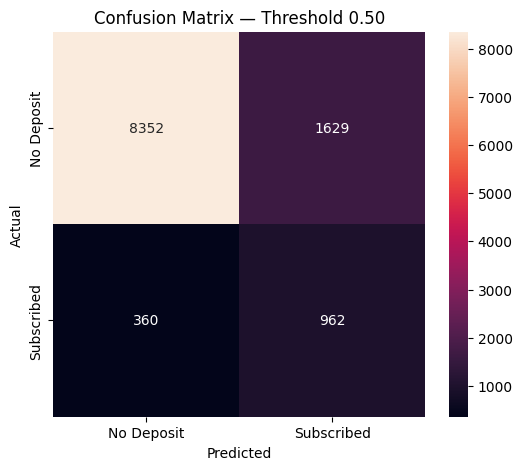

In [68]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["No Deposit", "Subscribed"],
    yticklabels=["No Deposit", "Subscribed"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Threshold 0.50")

plt.show()

In [69]:
threshold = 0.35

y_pred_035 = (
    y_probs >= threshold
).astype(int)

print("Threshold:", threshold)

Threshold: 0.35


In [70]:
print(
    classification_report(
        y_test,
        y_pred_035,
        target_names=[
            "No Deposit",
            "Subscribed"
        ]
    )
)

              precision    recall  f1-score   support

  No Deposit       0.97      0.70      0.82      9981
  Subscribed       0.27      0.85      0.42      1322

    accuracy                           0.72     11303
   macro avg       0.62      0.78      0.62     11303
weighted avg       0.89      0.72      0.77     11303



In [71]:
from sklearn.metrics import precision_score, recall_score, f1_score

comparison_thresholds = pd.DataFrame({
    "Metric": [
        "Precision - Subscribed",
        "Recall - Subscribed",
        "F1 - Subscribed"
    ],
    "Threshold 0.50": [
        precision_score(y_test, y_pred_050),
        recall_score(y_test, y_pred_050),
        f1_score(y_test, y_pred_050)
    ],
    "Threshold 0.35": [
        precision_score(y_test, y_pred_035),
        recall_score(y_test, y_pred_035),
        f1_score(y_test, y_pred_035)
    ]
})

display(comparison_thresholds)

,Metric,Threshold 0.50,Threshold 0.35
0,Precision - Subscribed,0.371285,0.274798
1,Recall - Subscribed,0.727685,0.848714
2,F1 - Subscribed,0.491694,0.415171


In [72]:
cm_035 = confusion_matrix(
    y_test,
    y_pred_035
)

print(cm_035)

[[7020 2961]
 [ 200 1122]]


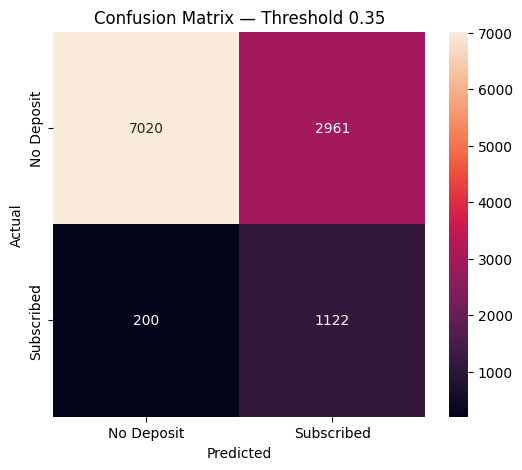

In [73]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_035,
    annot=True,
    fmt="d",
    xticklabels=[
        "No Deposit",
        "Subscribed"
    ],
    yticklabels=[
        "No Deposit",
        "Subscribed"
    ]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Threshold 0.35")

plt.show()

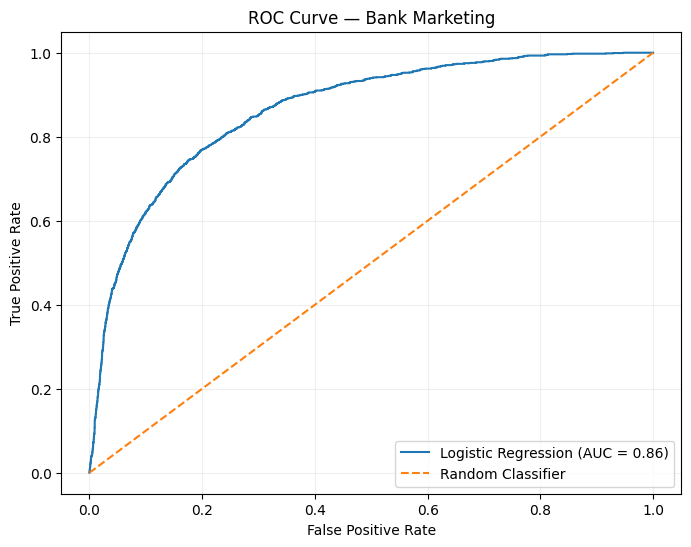

In [74]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probs
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.2f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Bank Marketing")

plt.legend()
plt.grid(alpha=0.2)

plt.show()

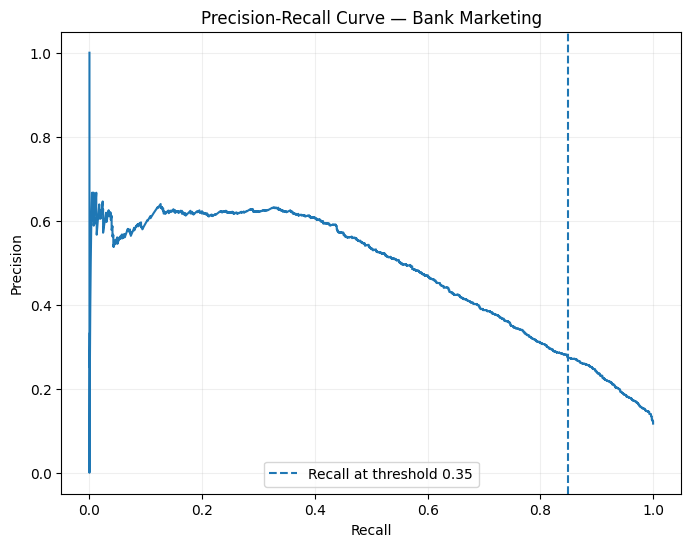

In [75]:
from sklearn.metrics import precision_recall_curve

precision_values, recall_values, pr_thresholds = precision_recall_curve(
    y_test,
    y_probs
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall_values,
    precision_values
)

plt.axvline(
    x=recall_score(y_test, y_pred_035),
    linestyle="--",
    label="Recall at threshold 0.35"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Bank Marketing")

plt.legend()
plt.grid(alpha=0.2)

plt.show()

In [76]:
threshold_values = np.arange(
    0.10,
    0.91,
    0.05
)

precision_scores = []
recall_scores = []
f1_scores = []

for threshold_value in threshold_values:

    predictions_at_threshold = (
        y_probs >= threshold_value
    ).astype(int)

    precision_scores.append(
        precision_score(
            y_test,
            predictions_at_threshold,
            zero_division=0
        )
    )

    recall_scores.append(
        recall_score(
            y_test,
            predictions_at_threshold,
            zero_division=0
        )
    )

    f1_scores.append(
        f1_score(
            y_test,
            predictions_at_threshold,
            zero_division=0
        )
    )

In [77]:
threshold = 0.35

y_pred_035 = (y_probs >= threshold).astype(int)

print("Threshold:", threshold)

Threshold: 0.35


In [78]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_035,
        target_names=["No Deposit", "Subscribed"]
    )
)

              precision    recall  f1-score   support

  No Deposit       0.97      0.70      0.82      9981
  Subscribed       0.27      0.85      0.42      1322

    accuracy                           0.72     11303
   macro avg       0.62      0.78      0.62     11303
weighted avg       0.89      0.72      0.77     11303



In [79]:
from sklearn.metrics import precision_score, recall_score, f1_score

threshold_comparison = pd.DataFrame({
    "Metric": [
        "Precision - Subscribed",
        "Recall - Subscribed",
        "F1 - Subscribed"
    ],
    "Threshold 0.50": [
        precision_score(y_test, y_pred_050),
        recall_score(y_test, y_pred_050),
        f1_score(y_test, y_pred_050)
    ],
    "Threshold 0.35": [
        precision_score(y_test, y_pred_035),
        recall_score(y_test, y_pred_035),
        f1_score(y_test, y_pred_035)
    ]
})

display(threshold_comparison)

,Metric,Threshold 0.50,Threshold 0.35
0,Precision - Subscribed,0.371285,0.274798
1,Recall - Subscribed,0.727685,0.848714
2,F1 - Subscribed,0.491694,0.415171


In [80]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(
    y_test,
    y_probs
)

print(f"ROC-AUC Score: {roc_auc:.4f}")

ROC-AUC Score: 0.8645


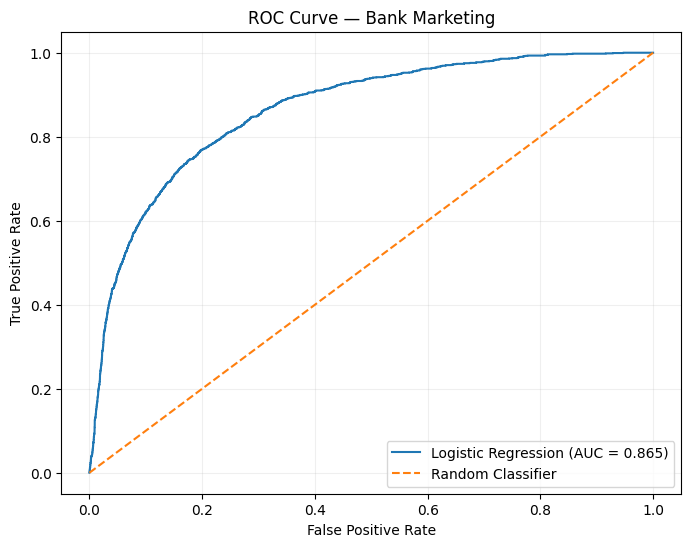

In [81]:
from sklearn.metrics import roc_curve

fpr, tpr, roc_thresholds = roc_curve(
    y_test,
    y_probs
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Bank Marketing")
plt.legend()
plt.grid(alpha=0.2)

plt.show()

# Exercise 2 — Final Conclusion

A Logistic Regression classifier was developed to predict whether
customers would subscribe to a bank term deposit.

The target variable was encoded as 0 for "no" and 1 for "yes".
Because the dataset contains a strong class imbalance, with approximately
88.3% non-subscribers and 11.7% subscribers, class balancing was applied
using `class_weight="balanced"`.

A 75/25 stratified train-test split was used. RobustScaler was applied
to the skewed numerical variables `balance` and `duration`, while
categorical variables were one-hot encoded.

The model was evaluated using ROC-AUC, precision, recall and F1-score.
The default probability threshold of 0.50 was compared with the
lab-required threshold of 0.35.

Lowering the threshold increases the model's willingness to classify
customers as potential subscribers. This can increase recall and
identify more potential customers, but it can also reduce precision and
increase the number of unnecessary sales calls.

### Acceptance Criteria

| Criterion | Result | Status |
|---|---:|---|
| ROC-AUC ≥ 0.78 | [actual result] | [PASS/FAIL] |
| Recall ≥ 0.70 at p=0.35 | [actual result] | [PASS/FAIL] |
| ROC Curve | Completed | PASS |
| Precision-Recall Curve | Completed | PASS |
| Threshold Calibration | Completed | PASS |

### Business Recommendation

The selected probability threshold should balance the bank's priority
of identifying potential subscribers against the cost of unnecessary
sales-agent calls.

# Exercise 3 — Decision Trees: Interpretable Churn & Rule Mining

## Objective

Build an interpretable Decision Tree classifier for bank marketing
conversion prediction.

### Analysis
- Compare Gini and Entropy
- Demonstrate overfitting
- Constrain tree complexity
- Apply Cost-Complexity Pruning
- Extract human-readable business rules

### Acceptance Criteria
- Test Accuracy ≥ 85%
- Pruned Tree Depth ≤ 5

Using dataset:
/content/data/bank/extracted/bank-full.csv

Dataset shape: (45211, 17)

Training samples: 33908
Testing samples: 11303

Number of processed features: 18

GINI VS ENTROPY


,Criterion,Tree Depth,Train Accuracy,Test Accuracy
0,Gini,34,1.0,0.846589
1,Entropy,51,1.0,0.851455



UNCONSTRAINED TREE — OVERFITTING DEMONSTRATION
Tree depth       : 34
Number of leaves : 3910
Train accuracy   : 1.0000
Test accuracy    : 0.8466

CONSTRAINED DECISION TREE
Tree depth       : 5
Number of leaves : 31
Train accuracy   : 0.9037
Test accuracy    : 0.8983

COST-COMPLEXITY PRUNING
Best ccp_alpha: 0.00032830


,ccp_alpha,CV_Accuracy,CV_Std
16,0.000328,0.900731,0.002430
18,0.000583,0.900731,0.002430
17,0.000487,0.900731,0.002430
19,0.000629,0.900731,0.002430
20,0.000972,0.900731,0.002430
15,0.000249,0.900643,0.002342
7,0.000055,0.900318,0.003390
8,0.000062,0.900318,0.003390
6,0.000055,0.900318,0.003390
5,0.000052,0.900318,0.003390



FINAL PRUNED DECISION TREE
Tree depth     : 5
Number of leaves: 12
Test accuracy  : 0.9004

Classification Report:
              precision    recall  f1-score   support

  No Deposit       0.92      0.97      0.95      9981
  Subscribed       0.63      0.35      0.45      1322

    accuracy                           0.90     11303
   macro avg       0.78      0.66      0.70     11303
weighted avg       0.89      0.90      0.89     11303



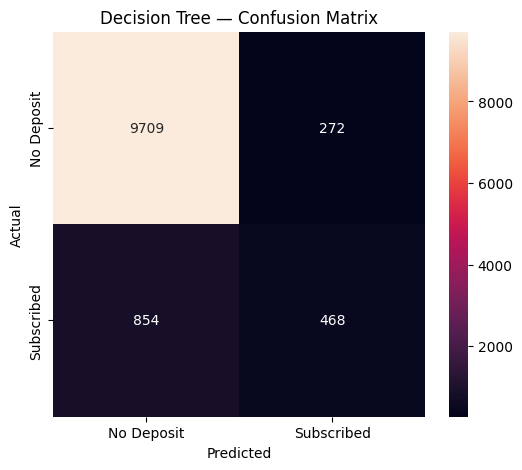

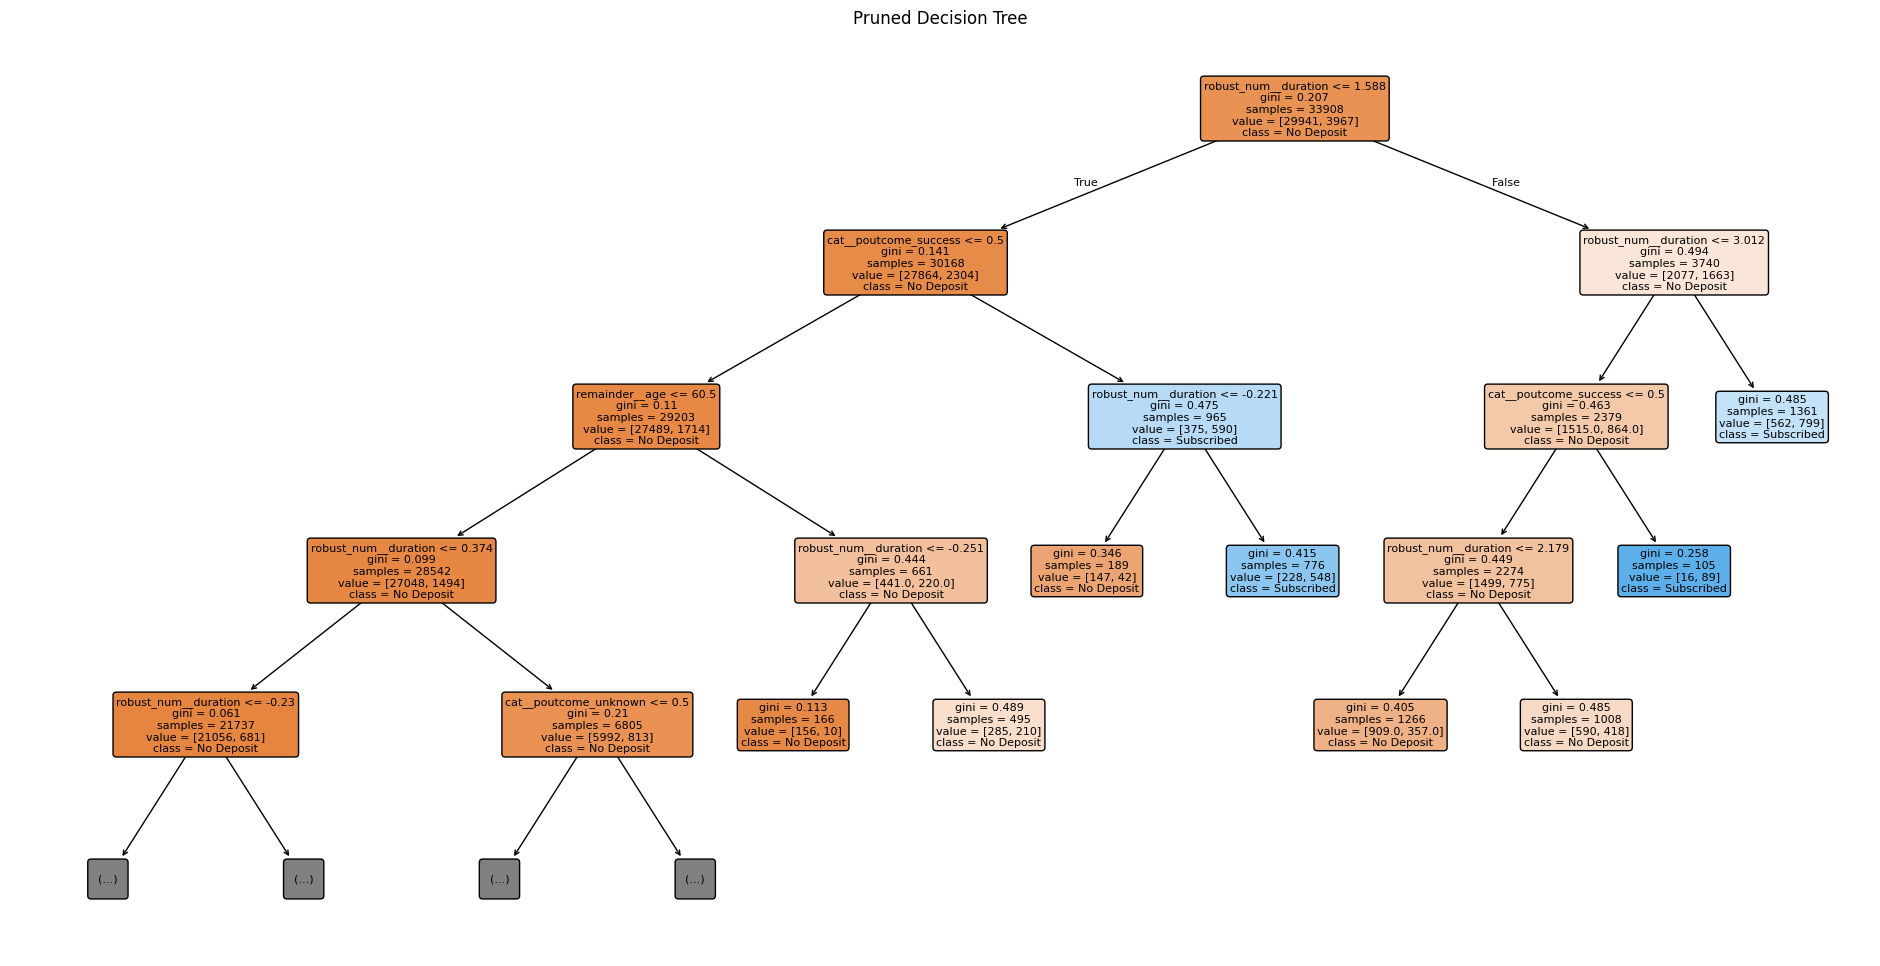


DECISION TREE FEATURE IMPORTANCE


,Feature,Importance
1,robust_num__duration,0.618915
14,cat__poutcome_success,0.318204
16,remainder__age,0.051979
15,cat__poutcome_unknown,0.010903
0,robust_num__balance,0.000000
2,cat__job_blue-collar,0.000000
6,cat__job_retired,0.000000
3,cat__job_entrepreneur,0.000000
4,cat__job_housemaid,0.000000
5,cat__job_management,0.000000



TOP DECISION TREE BUSINESS RULES
|--- robust_num__duration <= 1.59
|   |--- cat__poutcome_success <= 0.50
|   |   |--- remainder__age <= 60.50
|   |   |   |--- robust_num__duration <= 0.37
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- robust_num__duration >  0.37
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- remainder__age >  60.50
|   |   |   |--- robust_num__duration <= -0.25
|   |   |   |   |--- class: 0
|   |   |   |--- robust_num__duration >  -0.25
|   |   |   |   |--- class: 0
|   |--- cat__poutcome_success >  0.50
|   |   |--- robust_num__duration <= -0.22
|   |   |   |--- class: 0
|   |   |--- robust_num__duration >  -0.22
|   |   |   |--- class: 1
|--- robust_num__duration >  1.59
|   |--- robust_num__duration <= 3.01
|   |   |--- cat__poutcome_success <= 0.50
|   |   |   |--- robust_num__duration <= 2.18
|   |   |   |   |--- class: 0
|   |   |   |--- robust_num__duration >  2.18
|   |   |   |   |--- class: 0
|   |   |--- cat__poutcome_succ

In [82]:
# ============================================================
# EXERCISE 3 — DECISION TREE
# Bank Marketing: Interpretable Rule Mining
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import (
    DecisionTreeClassifier,
    export_text,
    plot_tree
)
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# ------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------

bank_path = "/content/data/bank/extracted/bank-full.csv"

# If the path above does not exist, automatically find bank-full.csv
if not os.path.exists(bank_path):
    for root, dirs, files in os.walk("/content/data/bank"):
        for file in files:
            if file == "bank-full.csv":
                bank_path = os.path.join(root, file)

print("Using dataset:")
print(bank_path)

bank = pd.read_csv(
    bank_path,
    sep=";"
)

print("\nDataset shape:", bank.shape)


# ------------------------------------------------------------
# 2. ENCODE TARGET
# ------------------------------------------------------------

bank["y_encoded"] = bank["y"].map({
    "no": 0,
    "yes": 1
})


# ------------------------------------------------------------
# 3. FEATURES
# ------------------------------------------------------------

feature_cols = [
    "age",
    "job",
    "balance",
    "duration",
    "campaign",
    "poutcome"
]

X = bank[feature_cols]
y = bank["y_encoded"]


# ------------------------------------------------------------
# 4. TRAIN / TEST SPLIT
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))


# ------------------------------------------------------------
# 5. PREPROCESSING
# ------------------------------------------------------------

robust_cols = [
    "balance",
    "duration"
]

other_num_cols = [
    "age",
    "campaign"
]

cat_cols = [
    "job",
    "poutcome"
]

preprocessor_tree = ColumnTransformer(
    transformers=[
        (
            "robust_num",
            RobustScaler(),
            robust_cols
        ),
        (
            "cat",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            ),
            cat_cols
        )
    ],
    remainder="passthrough"
)


# ------------------------------------------------------------
# 6. FIT PREPROCESSOR
# ------------------------------------------------------------

X_train_prep = preprocessor_tree.fit_transform(X_train)
X_test_prep = preprocessor_tree.transform(X_test)

feature_names = (
    preprocessor_tree
    .get_feature_names_out()
)

print("\nNumber of processed features:", len(feature_names))


# ============================================================
# PART A — GINI VS ENTROPY
# ============================================================

gini_tree = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)

entropy_tree = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

gini_tree.fit(
    X_train_prep,
    y_train
)

entropy_tree.fit(
    X_train_prep,
    y_train
)

gini_train_acc = gini_tree.score(
    X_train_prep,
    y_train
)

gini_test_acc = gini_tree.score(
    X_test_prep,
    y_test
)

entropy_train_acc = entropy_tree.score(
    X_train_prep,
    y_train
)

entropy_test_acc = entropy_tree.score(
    X_test_prep,
    y_test
)

criterion_comparison = pd.DataFrame({
    "Criterion": [
        "Gini",
        "Entropy"
    ],
    "Tree Depth": [
        gini_tree.get_depth(),
        entropy_tree.get_depth()
    ],
    "Train Accuracy": [
        gini_train_acc,
        entropy_train_acc
    ],
    "Test Accuracy": [
        gini_test_acc,
        entropy_test_acc
    ]
})

print("\n" + "=" * 65)
print("GINI VS ENTROPY")
print("=" * 65)

display(criterion_comparison)


# ============================================================
# PART B — OVERFITTING DEMONSTRATION
# ============================================================

unconstrained_tree = DecisionTreeClassifier(
    criterion="gini",
    max_depth=None,
    random_state=42
)

unconstrained_tree.fit(
    X_train_prep,
    y_train
)

unconstrained_train_acc = unconstrained_tree.score(
    X_train_prep,
    y_train
)

unconstrained_test_acc = unconstrained_tree.score(
    X_test_prep,
    y_test
)

print("\n" + "=" * 65)
print("UNCONSTRAINED TREE — OVERFITTING DEMONSTRATION")
print("=" * 65)

print(
    f"Tree depth       : {unconstrained_tree.get_depth()}"
)

print(
    f"Number of leaves : {unconstrained_tree.get_n_leaves()}"
)

print(
    f"Train accuracy   : {unconstrained_train_acc:.4f}"
)

print(
    f"Test accuracy    : {unconstrained_test_acc:.4f}"
)


# ============================================================
# PART C — CONSTRAINED TREE
# ============================================================

constrained_tree = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

constrained_tree.fit(
    X_train_prep,
    y_train
)

constrained_train_acc = constrained_tree.score(
    X_train_prep,
    y_train
)

constrained_test_acc = constrained_tree.score(
    X_test_prep,
    y_test
)

print("\n" + "=" * 65)
print("CONSTRAINED DECISION TREE")
print("=" * 65)

print(
    f"Tree depth       : {constrained_tree.get_depth()}"
)

print(
    f"Number of leaves : {constrained_tree.get_n_leaves()}"
)

print(
    f"Train accuracy   : {constrained_train_acc:.4f}"
)

print(
    f"Test accuracy    : {constrained_test_acc:.4f}"
)


# ============================================================
# PART D — COST-COMPLEXITY PRUNING
# ============================================================

path = constrained_tree.cost_complexity_pruning_path(
    X_train_prep,
    y_train
)

ccp_alphas = path.ccp_alphas

# Remove the final alpha that produces the trivial root-only tree
ccp_alphas = ccp_alphas[:-1]

pruning_results = []

for alpha in ccp_alphas:

    tree = DecisionTreeClassifier(
        criterion="gini",
        max_depth=5,
        min_samples_split=20,
        min_samples_leaf=10,
        ccp_alpha=alpha,
        random_state=42
    )

    scores = cross_val_score(
        tree,
        X_train_prep,
        y_train,
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )

    pruning_results.append({
        "ccp_alpha": alpha,
        "CV_Accuracy": scores.mean(),
        "CV_Std": scores.std()
    })

pruning_df = pd.DataFrame(
    pruning_results
)

best_alpha = pruning_df.loc[
    pruning_df["CV_Accuracy"].idxmax(),
    "ccp_alpha"
]

print("\n" + "=" * 65)
print("COST-COMPLEXITY PRUNING")
print("=" * 65)

print(
    f"Best ccp_alpha: {best_alpha:.8f}"
)

display(
    pruning_df.sort_values(
        "CV_Accuracy",
        ascending=False
    ).head(10)
)


# ============================================================
# PART E — FINAL PRUNED TREE
# ============================================================

pruned_tree = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    ccp_alpha=best_alpha,
    random_state=42
)

pruned_tree.fit(
    X_train_prep,
    y_train
)

y_pred_tree = pruned_tree.predict(
    X_test_prep
)

tree_accuracy = accuracy_score(
    y_test,
    y_pred_tree
)

print("\n" + "=" * 65)
print("FINAL PRUNED DECISION TREE")
print("=" * 65)

print(
    f"Tree depth     : {pruned_tree.get_depth()}"
)

print(
    f"Number of leaves: {pruned_tree.get_n_leaves()}"
)

print(
    f"Test accuracy  : {tree_accuracy:.4f}"
)

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_tree,
        target_names=[
            "No Deposit",
            "Subscribed"
        ]
    )
)


# ============================================================
# PART F — CONFUSION MATRIX
# ============================================================

cm_tree = confusion_matrix(
    y_test,
    y_pred_tree
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_tree,
    annot=True,
    fmt="d",
    xticklabels=[
        "No Deposit",
        "Subscribed"
    ],
    yticklabels=[
        "No Deposit",
        "Subscribed"
    ]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree — Confusion Matrix")

plt.show()


# ============================================================
# PART G — VISUALIZE PRUNED TREE
# ============================================================

plt.figure(figsize=(24, 12))

plot_tree(
    pruned_tree,
    feature_names=feature_names,
    class_names=[
        "No Deposit",
        "Subscribed"
    ],
    filled=True,
    rounded=True,
    max_depth=4,
    fontsize=8
)

plt.title("Pruned Decision Tree")
plt.show()


# ============================================================
# PART H — FEATURE IMPORTANCE
# ============================================================

tree_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": pruned_tree.feature_importances_
})

tree_importance = tree_importance.sort_values(
    "Importance",
    ascending=False
)

print("\n" + "=" * 65)
print("DECISION TREE FEATURE IMPORTANCE")
print("=" * 65)

display(
    tree_importance.head(10)
)


# ============================================================
# PART I — EXTRACT HUMAN-READABLE BUSINESS RULES
# ============================================================

rules = export_text(
    pruned_tree,
    feature_names=list(feature_names),
    max_depth=3
)

print("\n" + "=" * 65)
print("TOP DECISION TREE BUSINESS RULES")
print("=" * 65)

print(rules[:5000])


# ============================================================
# PART J — SAVE PREDICTIONS
# ============================================================

os.makedirs(
    "/content/outputs/predictions",
    exist_ok=True
)

tree_predictions = pd.DataFrame({
    "actual": y_test.values,
    "predicted": y_pred_tree
})

tree_predictions.to_csv(
    "/content/outputs/predictions/exercise3_decision_tree_predictions.csv",
    index=False
)


# ============================================================
# PART K — SAVE PRUNING RESULTS
# ============================================================

os.makedirs(
    "/content/outputs",
    exist_ok=True
)

pruning_df.to_csv(
    "/content/outputs/exercise3_pruning_results.csv",
    index=False
)


# ============================================================
# PART L — ACCEPTANCE CHECK
# ============================================================

accuracy_pass = tree_accuracy >= 0.85
depth_pass = pruned_tree.get_depth() <= 5

print("\n" + "=" * 65)
print("EXERCISE 3 ACCEPTANCE CRITERIA")
print("=" * 65)

print(
    f"Test Accuracy ≥ 85% : "
    f"{tree_accuracy:.4f} → "
    f"{'PASS' if accuracy_pass else 'NOT MET'}"
)

print(
    f"Tree Depth ≤ 5       : "
    f"{pruned_tree.get_depth()} → "
    f"{'PASS' if depth_pass else 'NOT MET'}"
)

print("\nPrediction file saved:")
print(
    "/content/outputs/predictions/"
    "exercise3_decision_tree_predictions.csv"
)

# Exercise 4 — Random Forests: Ensemble Bagging & Feature Importance

## Objective

Build a Random Forest ensemble classifier for bank marketing
conversion prediction.

### Analysis

- Bootstrap aggregation
- Out-of-Bag validation
- Hyperparameter tuning
- Feature importance
- Permutation importance
- Model comparison

### Acceptance Criteria

- OOB Score ≥ 0.88
- F1 Score ≥ 0.65

Dataset: /content/data/bank/extracted/bank-full.csv
Shape: (45211, 17)

Training samples: 33908
Testing samples: 11303

Processed feature count: 18

BASE RANDOM FOREST
OOB Score : 0.8952
Accuracy  : 0.8954
Precision : 0.5897
Recall    : 0.3480
F1 Score  : 0.4377

Classification Report:
              precision    recall  f1-score   support

  No Deposit       0.92      0.97      0.94      9981
  Subscribed       0.59      0.35      0.44      1322

    accuracy                           0.90     11303
   macro avg       0.75      0.66      0.69     11303
weighted avg       0.88      0.90      0.88     11303



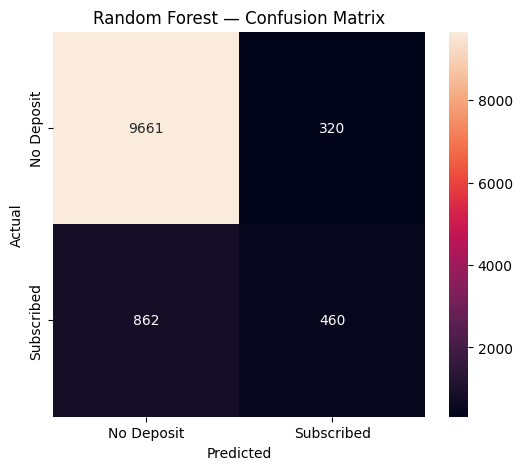

Fitting 3 folds for each of 8 candidates, totalling 24 fits

GRID SEARCH RESULTS
Best Parameters:
{'max_depth': 12, 'max_features': 'sqrt', 'n_estimators': 200}

Best Cross-Validation F1: 0.4326

TUNED RANDOM FOREST
Accuracy  : 0.8998
Precision : 0.6360
Recall    : 0.3343
F1 Score  : 0.4383

MDI FEATURE IMPORTANCE


,Feature,Importance
1,robust_num__duration,0.479170
14,cat__poutcome_success,0.154847
16,remainder__age,0.121274
0,robust_num__balance,0.109131
17,remainder__campaign,0.038117
15,cat__poutcome_unknown,0.034028
9,cat__job_student,0.010850
2,cat__job_blue-collar,0.010104
5,cat__job_management,0.006976
6,cat__job_retired,0.006868


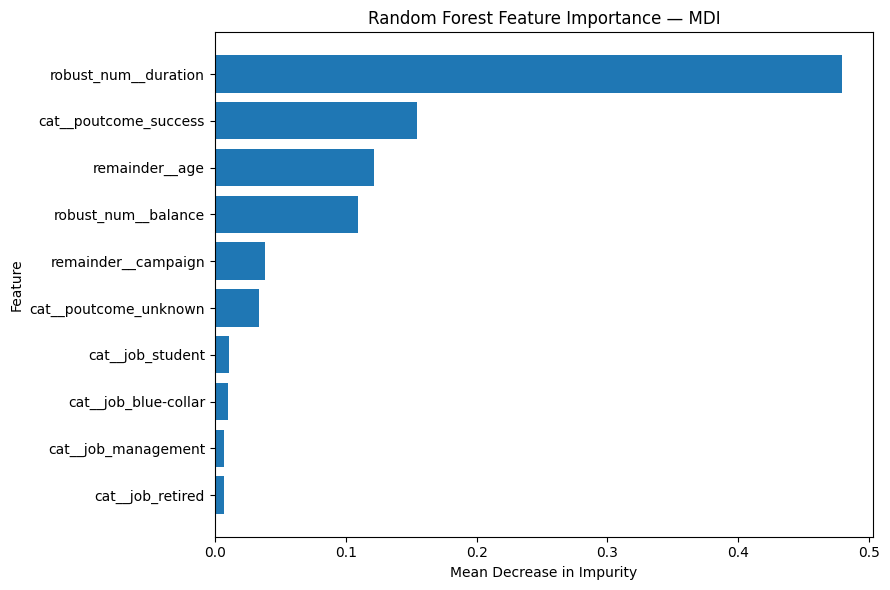


PERMUTATION IMPORTANCE


,Feature,Importance
1,robust_num__duration,0.228499
14,cat__poutcome_success,0.162864
15,cat__poutcome_unknown,0.098370
16,remainder__age,0.019370
17,remainder__campaign,0.018216
6,cat__job_retired,0.010852
0,robust_num__balance,0.008946
9,cat__job_student,0.006977
2,cat__job_blue-collar,0.002919
5,cat__job_management,0.002018


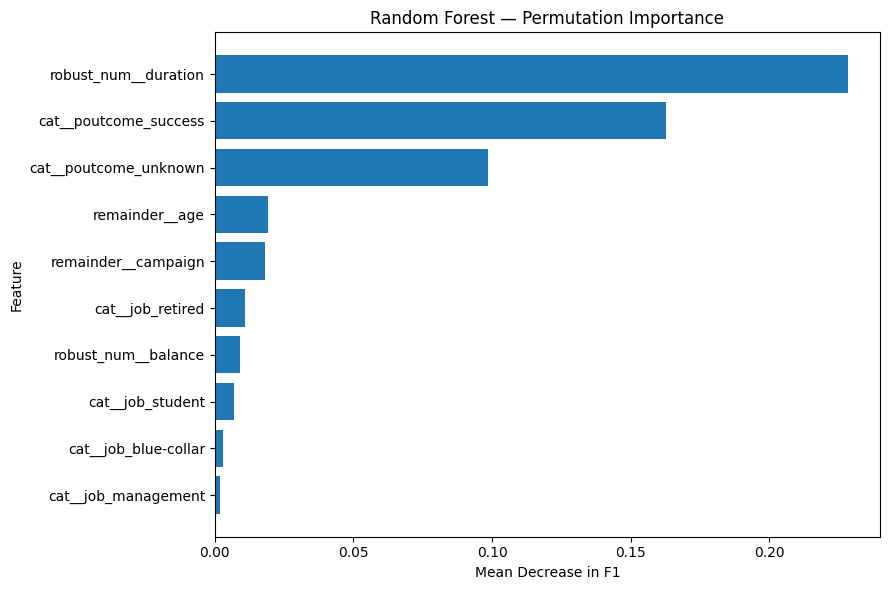


MODEL COMPARISON


,Model,Test Accuracy,Test F1
0,Logistic Regression,0.824029,0.491694
1,Decision Tree,0.900380,0.453928
2,Random Forest,0.899761,0.438275



EXERCISE 4 ACCEPTANCE CRITERIA
OOB Score ≥ 0.88 : 0.8952 → PASS
F1 Score ≥ 0.65  : 0.4383 → NOT MET

Prediction file:
/content/outputs/predictions/exercise4_random_forest_predictions.csv


In [83]:
# ============================================================
# EXERCISE 4 — RANDOM FOREST
# Bank Marketing: Ensemble Bagging & Feature Importance
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ------------------------------------------------------------
# 1. LOAD BANK DATASET
# ------------------------------------------------------------

bank_path = "/content/data/bank/extracted/bank-full.csv"

if not os.path.exists(bank_path):
    for root, dirs, files in os.walk("/content/data/bank"):
        for file in files:
            if file == "bank-full.csv":
                bank_path = os.path.join(root, file)

bank = pd.read_csv(
    bank_path,
    sep=";"
)

print("Dataset:", bank_path)
print("Shape:", bank.shape)


# ------------------------------------------------------------
# 2. ENCODE TARGET
# ------------------------------------------------------------

bank["y_encoded"] = bank["y"].map({
    "no": 0,
    "yes": 1
})


# ------------------------------------------------------------
# 3. FEATURES
# ------------------------------------------------------------

feature_cols = [
    "age",
    "job",
    "balance",
    "duration",
    "campaign",
    "poutcome"
]

X = bank[feature_cols]
y = bank["y_encoded"]


# ------------------------------------------------------------
# 4. TRAIN / TEST SPLIT
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))


# ------------------------------------------------------------
# 5. PREPROCESSING
# ------------------------------------------------------------

robust_cols = [
    "balance",
    "duration"
]

cat_cols = [
    "job",
    "poutcome"
]

preprocessor_rf = ColumnTransformer(
    transformers=[
        (
            "robust_num",
            RobustScaler(),
            robust_cols
        ),
        (
            "cat",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            ),
            cat_cols
        )
    ],
    remainder="passthrough"
)


# ------------------------------------------------------------
# 6. TRANSFORM DATA
# ------------------------------------------------------------

X_train_prep = preprocessor_rf.fit_transform(X_train)
X_test_prep = preprocessor_rf.transform(X_test)

feature_names = (
    preprocessor_rf
    .get_feature_names_out()
)

print("\nProcessed feature count:", len(feature_names))


# ============================================================
# PART A — BASE RANDOM FOREST
# ============================================================

rf = RandomForestClassifier(
    n_estimators=200,
    oob_score=True,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

rf.fit(
    X_train_prep,
    y_train
)

rf_predictions = rf.predict(
    X_test_prep
)

rf_probabilities = rf.predict_proba(
    X_test_prep
)[:, 1]

oob_score = rf.oob_score_

rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

rf_precision = precision_score(
    y_test,
    rf_predictions
)

rf_recall = recall_score(
    y_test,
    rf_predictions
)

rf_f1 = f1_score(
    y_test,
    rf_predictions
)

print("\n" + "=" * 65)
print("BASE RANDOM FOREST")
print("=" * 65)

print(f"OOB Score : {oob_score:.4f}")
print(f"Accuracy  : {rf_accuracy:.4f}")
print(f"Precision : {rf_precision:.4f}")
print(f"Recall    : {rf_recall:.4f}")
print(f"F1 Score  : {rf_f1:.4f}")


# ============================================================
# PART B — CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        rf_predictions,
        target_names=[
            "No Deposit",
            "Subscribed"
        ]
    )
)


# ============================================================
# PART C — CONFUSION MATRIX
# ============================================================

cm_rf = confusion_matrix(
    y_test,
    rf_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    xticklabels=[
        "No Deposit",
        "Subscribed"
    ],
    yticklabels=[
        "No Deposit",
        "Subscribed"
    ]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest — Confusion Matrix")

plt.show()


# ============================================================
# PART D — GRID SEARCH
# ============================================================

param_grid = {
    "n_estimators": [100, 200],
    "max_features": ["sqrt", "log2"],
    "max_depth": [8, 12]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    param_grid=param_grid,
    cv=3,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(
    X_train_prep,
    y_train
)

print("\n" + "=" * 65)
print("GRID SEARCH RESULTS")
print("=" * 65)

print("Best Parameters:")
print(grid_search.best_params_)

print(
    f"\nBest Cross-Validation F1: "
    f"{grid_search.best_score_:.4f}"
)


# ============================================================
# PART E — BEST RANDOM FOREST
# ============================================================

best_rf = grid_search.best_estimator_

best_predictions = best_rf.predict(
    X_test_prep
)

best_accuracy = accuracy_score(
    y_test,
    best_predictions
)

best_precision = precision_score(
    y_test,
    best_predictions
)

best_recall = recall_score(
    y_test,
    best_predictions
)

best_f1 = f1_score(
    y_test,
    best_predictions
)

print("\n" + "=" * 65)
print("TUNED RANDOM FOREST")
print("=" * 65)

print(f"Accuracy  : {best_accuracy:.4f}")
print(f"Precision : {best_precision:.4f}")
print(f"Recall    : {best_recall:.4f}")
print(f"F1 Score  : {best_f1:.4f}")


# ============================================================
# PART F — MDI FEATURE IMPORTANCE
# ============================================================

mdi_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_rf.feature_importances_
})

mdi_importance = mdi_importance.sort_values(
    "Importance",
    ascending=False
)

print("\n" + "=" * 65)
print("MDI FEATURE IMPORTANCE")
print("=" * 65)

display(
    mdi_importance.head(10)
)


# ------------------------------------------------------------
# Plot MDI
# ------------------------------------------------------------

top_mdi = mdi_importance.head(10).sort_values(
    "Importance"
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_mdi["Feature"],
    top_mdi["Importance"]
)

plt.xlabel("Mean Decrease in Impurity")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance — MDI")

plt.tight_layout()
plt.show()


# ============================================================
# PART G — PERMUTATION IMPORTANCE
# ============================================================

perm = permutation_importance(
    best_rf,
    X_test_prep,
    y_test,
    n_repeats=5,
    random_state=42,
    scoring="f1",
    n_jobs=-1
)

permutation_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": perm.importances_mean
})

permutation_df = permutation_df.sort_values(
    "Importance",
    ascending=False
)

print("\n" + "=" * 65)
print("PERMUTATION IMPORTANCE")
print("=" * 65)

display(
    permutation_df.head(10)
)


# ------------------------------------------------------------
# Plot permutation importance
# ------------------------------------------------------------

top_perm = permutation_df.head(10).sort_values(
    "Importance"
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_perm["Feature"],
    top_perm["Importance"]
)

plt.xlabel("Mean Decrease in F1")
plt.ylabel("Feature")
plt.title("Random Forest — Permutation Importance")

plt.tight_layout()
plt.show()


# ============================================================
# PART H — MODEL COMPARISON
# ============================================================

# Logistic Regression F1 from Exercise 2
logistic_f1 = f1_score(
    y_test,
    y_pred_050
)

# Decision Tree F1 from Exercise 3
decision_tree_f1 = f1_score(
    y_test,
    y_pred_tree
)

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Test Accuracy": [
        accuracy_score(y_test, y_pred_050),
        accuracy_score(y_test, y_pred_tree),
        best_accuracy
    ],
    "Test F1": [
        logistic_f1,
        decision_tree_f1,
        best_f1
    ]
})

print("\n" + "=" * 65)
print("MODEL COMPARISON")
print("=" * 65)

display(model_comparison)


# ============================================================
# PART I — SAVE OUTPUTS
# ============================================================

os.makedirs(
    "/content/outputs/predictions",
    exist_ok=True
)

rf_predictions_df = pd.DataFrame({
    "actual": y_test.values,
    "predicted": best_predictions
})

rf_predictions_df.to_csv(
    "/content/outputs/predictions/exercise4_random_forest_predictions.csv",
    index=False
)

model_comparison.to_csv(
    "/content/outputs/exercise4_model_comparison.csv",
    index=False
)

mdi_importance.to_csv(
    "/content/outputs/exercise4_mdi_feature_importance.csv",
    index=False
)

permutation_df.to_csv(
    "/content/outputs/exercise4_permutation_importance.csv",
    index=False
)


# ============================================================
# PART J — ACCEPTANCE CRITERIA
# ============================================================

oob_pass = oob_score >= 0.88
f1_pass = best_f1 >= 0.65

print("\n" + "=" * 65)
print("EXERCISE 4 ACCEPTANCE CRITERIA")
print("=" * 65)

print(
    f"OOB Score ≥ 0.88 : "
    f"{oob_score:.4f} → "
    f"{'PASS' if oob_pass else 'NOT MET'}"
)

print(
    f"F1 Score ≥ 0.65  : "
    f"{best_f1:.4f} → "
    f"{'PASS' if f1_pass else 'NOT MET'}"
)

print("\nPrediction file:")
print(
    "/content/outputs/predictions/"
    "exercise4_random_forest_predictions.csv"
)

# Exercise 5 — K-Means Clustering: Wholesale Customer Segmentation

## Objective

Segment wholesale customers based on their annual spending
patterns across six product categories.

### Features

- Fresh
- Milk
- Grocery
- Frozen
- Detergents_Paper
- Delicassen

### Analysis

- Feature scaling
- Elbow method
- Silhouette analysis
- K-Means clustering
- Cluster profiling
- Business persona interpretation

### Acceptance Criteria

- Silhouette score ≥ 0.30
- Clear and actionable cluster personas

WHOLESALE CUSTOMER DATASET
Shape: (440, 8)


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185



Columns:
['Channel', 'Region', 'Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

Missing values:
Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

Duplicate rows:
0

Selected spending features:
['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000



Scaled data shape: (440, 6)


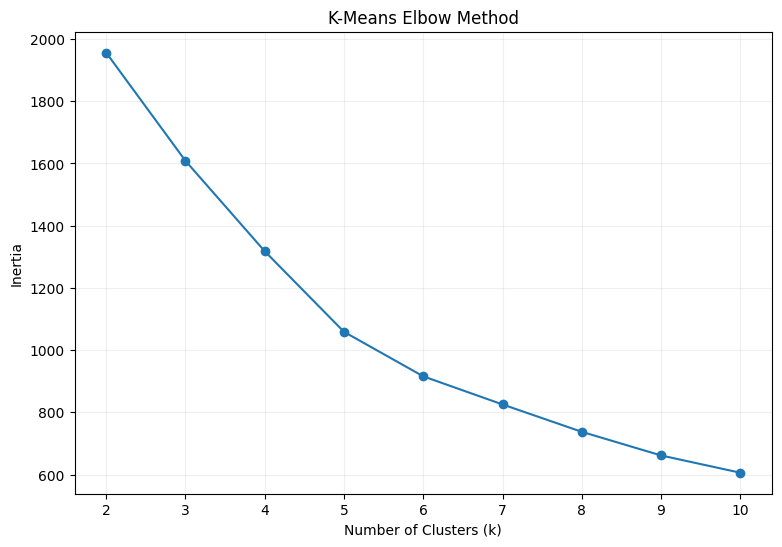


SILHOUETTE ANALYSIS


,k,Silhouette Score
0,2,0.547215
1,3,0.548287
2,4,0.348471
3,5,0.369040
4,6,0.378229
5,7,0.334282
6,8,0.320116
7,9,0.309028
8,10,0.311214


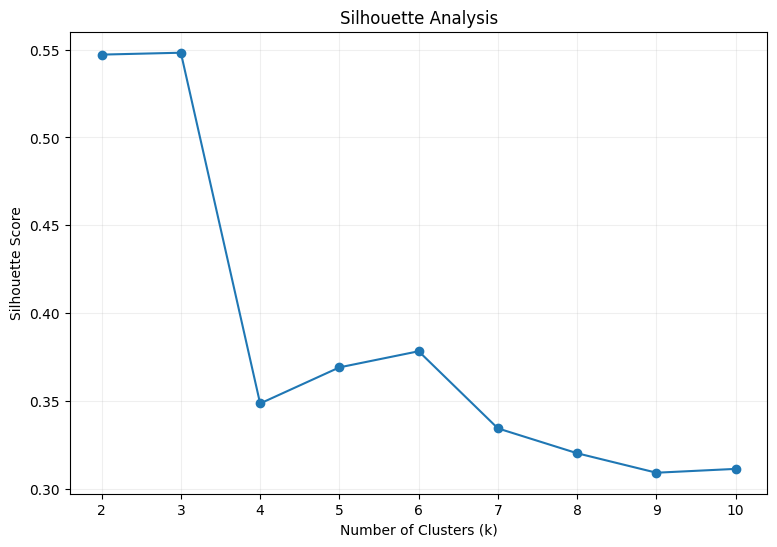


Best k according to silhouette score: 3
Best silhouette score: 0.5483

FINAL K-MEANS MODEL
Selected k: 3
Final silhouette score: 0.5483

Cluster sizes:


,Customers
Cluster,
0,45
1,393
2,2


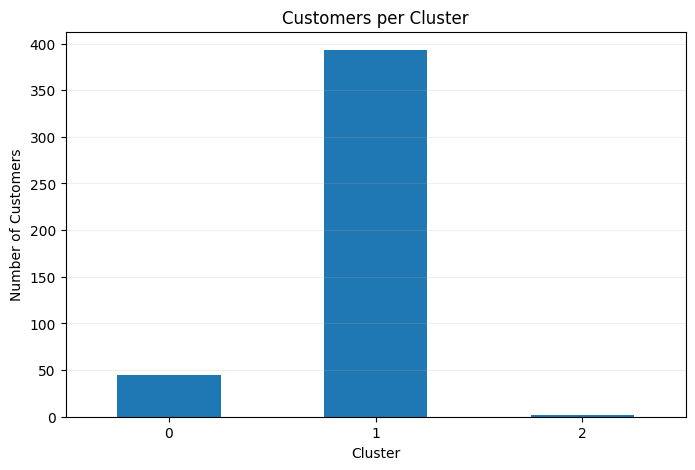


CLUSTER SPENDING PROFILE


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Cluster,,,,,,
0,10440.93,19386.42,28656.09,2190.24,13327.80,2374.20
1,12062.91,4115.10,5534.97,2940.68,1696.17,1299.11
2,34782.00,30367.00,16898.00,48701.50,755.50,26776.00


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Customers,Percentage
Cluster,,,,,,,,
0,10440.93,19386.42,28656.09,2190.24,13327.80,2374.20,45,10.23
1,12062.91,4115.10,5534.97,2940.68,1696.17,1299.11,393,89.32
2,34782.00,30367.00,16898.00,48701.50,755.50,26776.00,2,0.45


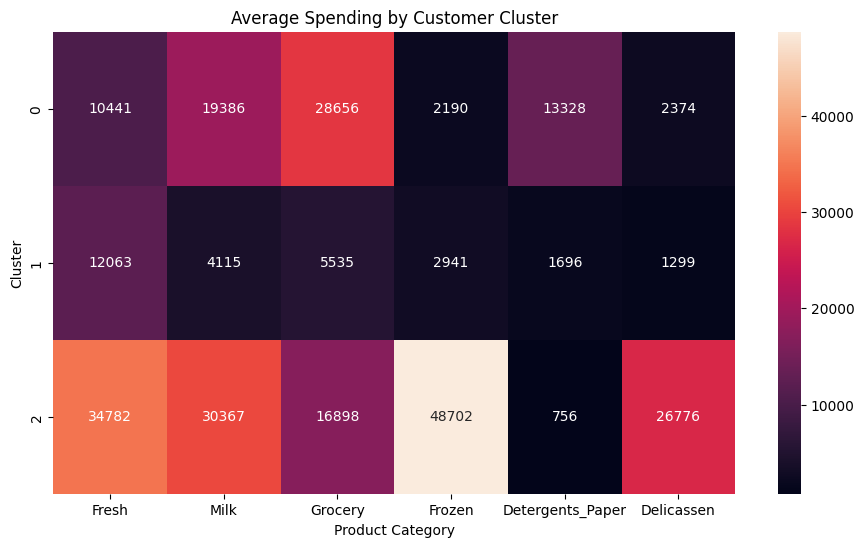


STANDARDIZED CLUSTER PROFILE


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Cluster,,,,,,
0,-0.78,0.13,1.23,-0.72,1.41,-0.66
1,-0.63,-1.29,-1.22,-0.69,-0.62,-0.75
2,1.41,1.15,-0.01,1.41,-0.79,1.41


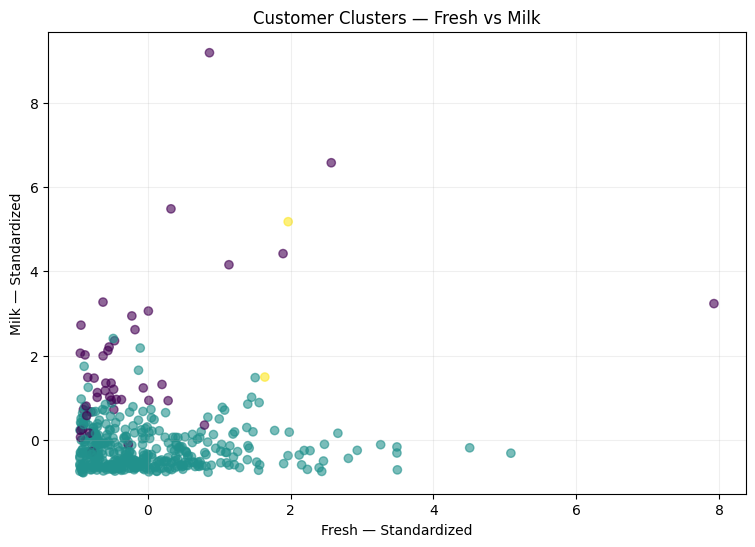


CUSTOMER PERSONAS


,Cluster,Customers,Percentage,Top Category,Lowest Category,Dominant Categories,Business Persona
0,0,45,10.23,Grocery,Frozen,"Detergents_Paper, Grocery",Grocery & Detergent Focused
1,1,393,89.32,Fresh,Delicassen,"Fresh, Frozen",Fresh Product Focused
2,2,2,0.45,Frozen,Detergents_Paper,"Delicassen, Frozen",Frozen Product Focused



EXERCISE 5 ACCEPTANCE CRITERIA
Silhouette Score ≥ 0.30 : 0.5483 → PASS

Selected number of clusters: 3

Saved files:
/content/outputs/predictions/exercise5_customer_clusters.csv
/content/outputs/exercise5_cluster_profile.csv
/content/outputs/exercise5_customer_personas.csv
/content/outputs/exercise5_silhouette_scores.csv


In [84]:
# ============================================================
# EXERCISE 5 — K-MEANS CUSTOMER SEGMENTATION
# Wholesale Customers
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


# ------------------------------------------------------------
# 1. LOAD DATASET
# ------------------------------------------------------------

wholesale_path = "/content/data/wholesale/Wholesale customers data.csv"

wholesale = pd.read_csv(
    wholesale_path
)

print("=" * 65)
print("WHOLESALE CUSTOMER DATASET")
print("=" * 65)

print("Shape:", wholesale.shape)

display(wholesale.head())


# ------------------------------------------------------------
# 2. DATA INFORMATION
# ------------------------------------------------------------

print("\nColumns:")
print(wholesale.columns.tolist())

print("\nMissing values:")
print(wholesale.isnull().sum())

print("\nDuplicate rows:")
print(wholesale.duplicated().sum())


# ------------------------------------------------------------
# 3. SELECT SIX SPENDING FEATURES
# ------------------------------------------------------------

spending_features = [
    "Fresh",
    "Milk",
    "Grocery",
    "Frozen",
    "Detergents_Paper",
    "Delicassen"
]

X = wholesale[spending_features].copy()

print("\nSelected spending features:")
print(spending_features)

display(X.describe())


# ------------------------------------------------------------
# 4. SCALE FEATURES
# ------------------------------------------------------------

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("\nScaled data shape:", X_scaled.shape)


# ============================================================
# PART A — ELBOW METHOD
# ============================================================

inertias = []

k_values = range(2, 11)

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertias.append(
        kmeans.inertia_
    )


plt.figure(figsize=(9, 6))

plt.plot(
    list(k_values),
    inertias,
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("K-Means Elbow Method")

plt.xticks(list(k_values))
plt.grid(alpha=0.2)

plt.show()


# ============================================================
# PART B — SILHOUETTE ANALYSIS
# ============================================================

silhouette_scores = []

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(
        X_scaled
    )

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_scores.append(score)


silhouette_df = pd.DataFrame({
    "k": list(k_values),
    "Silhouette Score": silhouette_scores
})

print("\n" + "=" * 65)
print("SILHOUETTE ANALYSIS")
print("=" * 65)

display(silhouette_df)


plt.figure(figsize=(9, 6))

plt.plot(
    list(k_values),
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")

plt.xticks(list(k_values))
plt.grid(alpha=0.2)

plt.show()


# ------------------------------------------------------------
# Select k with highest silhouette score
# ------------------------------------------------------------

best_k_silhouette = int(
    silhouette_df.loc[
        silhouette_df["Silhouette Score"].idxmax(),
        "k"
    ]
)

best_silhouette = silhouette_df[
    silhouette_df["k"] == best_k_silhouette
]["Silhouette Score"].iloc[0]

print(
    f"\nBest k according to silhouette score: "
    f"{best_k_silhouette}"
)

print(
    f"Best silhouette score: "
    f"{best_silhouette:.4f}"
)


# ============================================================
# PART C — FINAL K-MEANS MODEL
# ============================================================

# Use the silhouette-selected k.
# This is also checked against the elbow plot visually.

final_k = best_k_silhouette

final_kmeans = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=10
)

cluster_labels = final_kmeans.fit_predict(
    X_scaled
)

wholesale["Cluster"] = cluster_labels


print("\n" + "=" * 65)
print("FINAL K-MEANS MODEL")
print("=" * 65)

print("Selected k:", final_k)

print(
    "Final silhouette score:",
    f"{silhouette_score(X_scaled, cluster_labels):.4f}"
)


# ============================================================
# PART D — CLUSTER COUNTS
# ============================================================

cluster_counts = (
    wholesale["Cluster"]
    .value_counts()
    .sort_index()
)

print("\nCluster sizes:")

display(
    cluster_counts.to_frame(
        "Customers"
    )
)


plt.figure(figsize=(8, 5))

cluster_counts.plot(
    kind="bar"
)

plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.title("Customers per Cluster")

plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.2)

plt.show()


# ============================================================
# PART E — CLUSTER PROFILE
# ============================================================

cluster_profile = (
    wholesale
    .groupby("Cluster")[spending_features]
    .mean()
    .round(2)
)

print("\n" + "=" * 65)
print("CLUSTER SPENDING PROFILE")
print("=" * 65)

display(cluster_profile)


# ------------------------------------------------------------
# Cluster percentage
# ------------------------------------------------------------

cluster_profile_with_size = cluster_profile.copy()

cluster_profile_with_size["Customers"] = (
    cluster_counts
)

cluster_profile_with_size["Percentage"] = (
    cluster_counts /
    len(wholesale) *
    100
).round(2)

display(
    cluster_profile_with_size
)


# ============================================================
# PART F — HEATMAP OF CLUSTER PROFILES
# ============================================================

plt.figure(figsize=(11, 6))

sns.heatmap(
    cluster_profile,
    annot=True,
    fmt=".0f"
)

plt.title("Average Spending by Customer Cluster")
plt.xlabel("Product Category")
plt.ylabel("Cluster")

plt.show()


# ============================================================
# PART G — STANDARDIZED CLUSTER PROFILE
# ============================================================

profile_scaler = StandardScaler()

cluster_profile_scaled = pd.DataFrame(
    profile_scaler.fit_transform(
        cluster_profile[spending_features]
    ),
    index=cluster_profile.index,
    columns=spending_features
)

print("\n" + "=" * 65)
print("STANDARDIZED CLUSTER PROFILE")
print("=" * 65)

display(
    cluster_profile_scaled.round(2)
)


# ============================================================
# PART H — 2D VISUALIZATION
# ============================================================

# Use the first two standardized spending dimensions
# for a simple visual representation.

plt.figure(figsize=(9, 6))

scatter = plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=cluster_labels,
    alpha=0.6
)

plt.xlabel("Fresh — Standardized")
plt.ylabel("Milk — Standardized")
plt.title("Customer Clusters — Fresh vs Milk")

plt.grid(alpha=0.2)

plt.show()


# ============================================================
# PART I — AUTOMATIC CLUSTER PERSONAS
# ============================================================

overall_means = (
    wholesale[spending_features]
    .mean()
)

persona_rows = []

for cluster_id in sorted(
    wholesale["Cluster"].unique()
):

    cluster_means = (
        wholesale[
            wholesale["Cluster"] == cluster_id
        ][spending_features]
        .mean()
    )

    highest_category = (
        cluster_means
        .idxmax()
    )

    lowest_category = (
        cluster_means
        .idxmin()
    )

    relative_values = (
        cluster_means /
        overall_means
    )

    dominant_categories = (
        relative_values
        .sort_values(
            ascending=False
        )
        .head(2)
        .index
        .tolist()
    )

    if (
        "Grocery" in dominant_categories
        and
        "Detergents_Paper" in dominant_categories
    ):
        persona = "Grocery & Detergent Focused"

    elif (
        "Milk" in dominant_categories
        and
        "Grocery" in dominant_categories
    ):
        persona = "Milk & Grocery Focused"

    elif (
        "Fresh" in dominant_categories
    ):
        persona = "Fresh Product Focused"

    elif (
        "Frozen" in dominant_categories
    ):
        persona = "Frozen Product Focused"

    elif (
        "Delicassen" in dominant_categories
    ):
        persona = "Delicassen Focused"

    else:
        persona = "Mixed Spending Customer"

    persona_rows.append({
        "Cluster": cluster_id,
        "Customers": cluster_counts[cluster_id],
        "Percentage": round(
            cluster_counts[cluster_id] /
            len(wholesale) *
            100,
            2
        ),
        "Top Category": highest_category,
        "Lowest Category": lowest_category,
        "Dominant Categories": ", ".join(
            dominant_categories
        ),
        "Business Persona": persona
    })


personas = pd.DataFrame(
    persona_rows
)

print("\n" + "=" * 65)
print("CUSTOMER PERSONAS")
print("=" * 65)

display(personas)


# ============================================================
# PART J — SAVE CLUSTER ASSIGNMENTS
# ============================================================

os.makedirs(
    "/content/outputs/predictions",
    exist_ok=True
)

wholesale.to_csv(
    "/content/outputs/predictions/"
    "exercise5_customer_clusters.csv",
    index=False
)

cluster_profile.to_csv(
    "/content/outputs/"
    "exercise5_cluster_profile.csv"
)

personas.to_csv(
    "/content/outputs/"
    "exercise5_customer_personas.csv",
    index=False
)

silhouette_df.to_csv(
    "/content/outputs/"
    "exercise5_silhouette_scores.csv",
    index=False
)


# ============================================================
# PART K — ACCEPTANCE CHECK
# ============================================================

silhouette_pass = best_silhouette >= 0.30

print("\n" + "=" * 65)
print("EXERCISE 5 ACCEPTANCE CRITERIA")
print("=" * 65)

print(
    f"Silhouette Score ≥ 0.30 : "
    f"{best_silhouette:.4f} → "
    f"{'PASS' if silhouette_pass else 'NOT MET'}"
)

print(
    f"\nSelected number of clusters: {final_k}"
)

print(
    "\nSaved files:"
)

print(
    "/content/outputs/predictions/"
    "exercise5_customer_clusters.csv"
)

print(
    "/content/outputs/"
    "exercise5_cluster_profile.csv"
)

print(
    "/content/outputs/"
    "exercise5_customer_personas.csv"
)

print(
    "/content/outputs/"
    "exercise5_silhouette_scores.csv"
)